# Phase 2a - LIME: Local Interpretable Model-Agnostic Explanations

**DOLPH-X Pipeline | Master 2 MIAGE**

**Description:** Generates local LIME explanations for the 13 representative instances selected in Phase 1. Computes fidelity and stability metrics to assess explanation quality.

**Input:** `evaluator.pkl`

**Output:** `outputs/lime_explanations.csv`

## 1. Imports

In [20]:
# IMPORTS
from MLEvaluator import MLEvaluator
from XAIEvaluator import XAIEvaluator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs('outputs', exist_ok=True)
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')


# LIME: import direct sans try/except
from lime.lime_tabular import LimeTabularExplainer
LIME_AVAILABLE = True
print('OK LIME disponible')

OK LIME disponible


## 2. Load Evaluator

In [24]:
evaluator = MLEvaluator.load('evaluator.pkl')

Evaluator loaded from 'evaluator.pkl'
  Available models: ['SVM', 'Logistic_Regression', 'Decision_Tree', 'KNN', 'Naive_Bayes', 'Random_Forest', 'Extra_Trees', 'Bagging', 'Gradient_Boosting', 'MLP', 'XGBoost']


## 3. LIMEEvaluator Class

In [26]:

# CLASSE LIME
class LIMEEvaluator(XAIEvaluator):


    def __init__(self, evaluator):
        super().__init__(evaluator)  
        self.explainer       = None
        self.mc_lime_results = {}
        self.lime_explanations  = {}  
        self.export_rows     = []
        self.evaluation_results = pd.DataFrame()

  
    # Block 2: Create explainer
    def create_explainer(self):
        from lime.lime_tabular import LimeTabularExplainer
        self.explainer = LimeTabularExplainer(
            self.X_train.values,
            feature_names=self.feature_names,
            class_names=self.CLASS_NAMES,
            mode='classification',
            discretize_continuous=False,
            random_state=42,
        )
        print('OK LimeTabularExplainer créé')
   

    # Block 3: Generate explanations
    def generate_explanations(self):
        print('\n GENERATING LIME EXPLANATIONS')
        print('=' * 50)
    
        for model_name, model in self.trained_models.items():
            if model_name not in self.SELECTED_MODELS:
                print(f'  {model_name} -> ignoré (hors sélection)')
                continue
            if not hasattr(model, 'predict_proba'):
                print(f'  {model_name} -> ignoré (pas de predict_proba)')
                continue
    
            print(f'\n  {model_name}...')
            model_explanations = []

            for class_name, sample_indices in self.selected_samples.items():
                for sample_idx in sample_indices:
                    try:
                        instance = self.X_test.iloc[sample_idx].values

                        predicted  = int(model.predict([instance])[0])
                        true_label = int(self.y_test.iloc[sample_idx])
                        if predicted != true_label:
                            print(f'    WARNING {model_name} se trompe sur instance {sample_idx} -> ignorée')
                            continue
                        exp = self.explainer.explain_instance(
                            instance, model.predict_proba,
                            num_features=min(10, len(self.feature_names)),
                        )
                        model_explanations.append({
                            'instance_id'          : sample_idx,
                            'class_name'           : class_name,
                            'true_label'           : int(self.y_test.iloc[sample_idx]),
                            'predicted_label'      : int(model.predict([instance])[0]),
                            'prediction_proba'     : model.predict_proba([instance])[0].tolist(),
                            'feature_contributions': exp.as_list(),
                            'instance_values'      : self.X_test.iloc[sample_idx].to_dict(),
                        })
                    except Exception as e:
                        print(f'    Échec sample {sample_idx} : {e}')

            self.lime_explanations[model_name] = model_explanations
            print(f'    -> {len(model_explanations)} explications OK')

    # Block 4: Visualisation
    def plot_explanations(self):
        print('\n VISUALISATION')
        for model_name, explanations in self.lime_explanations.items():
            if not explanations:
                continue
            by_class = {}
            for exp in explanations:
                by_class.setdefault(exp['class_name'], []).append(exp)

            for class_name, class_exps in by_class.items():
                n = len(class_exps)
                fig, axes = plt.subplots(n, 1, figsize=(12, 4 * n))
                if n == 1:
                    axes = [axes]
                fig.suptitle(f'LIME: {model_name}: Profil {class_name}',
                             fontsize=14, fontweight='bold')

                for idx, exp_data in enumerate(class_exps):
                    ax = axes[idx]
                    features, contribs = zip(*exp_data['feature_contributions'])
                    bar_colors = ['#D85A30' if c < 0 else '#1D9E75' for c in contribs]
                    y_pos = np.arange(len(features))
                    bars = ax.barh(y_pos, contribs, color=bar_colors, alpha=0.8)
                    ax.set_yticks(y_pos)
                    ax.set_yticklabels(
                        [f[:35] + '...' if len(f) > 35 else f for f in features], fontsize=8)
                    mn, mx = min(contribs), max(contribs)
                    pad = (mx - mn) * 0.2 if mx != mn else 0.005
                    ax.set_xlim(mn - pad, mx + pad)
                    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
                    ax.set_title(
                        f'Instance {exp_data["instance_id"]}: '
                        f'Vrai : {self.CLASS_NAMES[exp_data["true_label"]]} | '
                        f'Prédit : {self.CLASS_NAMES[exp_data["predicted_label"]]}',
                        fontsize=10)
                    ax.grid(axis='x', alpha=0.3)
                    for bar, val in zip(bars, contribs):
                        w = bar.get_width()
                        offset = 0.02 * max(abs(w), 0.001)
                        ax.text(w + offset if w >= 0 else w - offset,
                                bar.get_y() + bar.get_height() / 2,
                                f'{val:.4f}', ha='left' if w >= 0 else 'right',
                                va='center', fontsize=7)

                plt.tight_layout()
                plt.savefig(f'outputs/lime_{model_name}_{class_name}.png',
                            dpi=150, bbox_inches='tight')
                plt.show()

    # Block 5: Quality metrics
    def _local_fidelity(self, model, instance, n_samples=200):
        try:
            exp = self.explainer.explain_instance(
                instance, model.predict_proba, num_features=10, num_samples=n_samples)
            weights = dict(exp.as_list())
            pred_class = np.argmax(model.predict_proba([instance])[0])
            np.random.seed(42)
            noise = np.std(instance) * 0.1 if np.std(instance) > 0 else 0.01
            perturbed = instance + np.random.normal(0, noise, (n_samples, len(instance)))
            real_preds = model.predict_proba(perturbed)[:, pred_class]
            intercept = exp.intercept.get(pred_class, 0) if hasattr(exp, 'intercept') else 0
            lime_preds = np.array([
                intercept + sum(weights.get(self.feature_names[i], 0) * p[i]
                                for i in range(len(self.feature_names)))
                for p in perturbed])
            if len(set(real_preds)) > 1 and len(set(lime_preds)) > 1:
                corr, _ = pearsonr(real_preds, lime_preds)
                return max(0.0, corr)
            return 0.0
        except:
            return 0.0

    def _stability(self, model, instance, n_runs=10):
        try:
            runs = []
            for seed in range(n_runs):
                np.random.seed(seed)
                exp = self.explainer.explain_instance(
                    instance, model.predict_proba, num_features=10, num_samples=10000)
                runs.append(dict(exp.as_list()))
            all_features = sorted(set(k for d in runs for k in d))
            matrix = np.array([[d.get(f, 0.0) for f in all_features] for d in runs])
            stabs = []
            for col in matrix.T:
                mean_abs = np.mean(np.abs(col))
                stabs.append(1 / (1 + np.std(col) / mean_abs) if mean_abs > 1e-6 else 1.0)
            return np.mean(stabs)
        except:
            return 0.0

    def evaluate_quality(self):
        print('\n LIME EXPLANATION QUALITY EVALUATION')
        print('=' * 50)
        results = []
        for model_name, model in self.trained_models.items():
            if not hasattr(model, 'predict_proba'):
                continue
            print(f'\n  {model_name}')
            fids, stabs = [], []
            for class_name, sample_indices in self.selected_samples.items():
                for sample_idx in sample_indices[:2]:  # 2 par profil
                    instance = self.X_test.iloc[sample_idx].values
                    fid = self._local_fidelity(model, instance)
                    sta = self._stability(model, instance)
                    fids.append(fid)
                    stabs.append(sta)
                    print(f'    [{class_name}] instance {sample_idx} : '
                          f'Fidélité={fid:.3f}  Stabilité={sta:.3f}')
            if fids:
                results.append({'Model': model_name,
                                'Fidélité_moy': round(np.mean(fids), 3),
                                'Fidélité_std': round(np.std(fids), 3),
                                'Stabilité_moy': round(np.mean(stabs), 3),
                                'Stabilité_std': round(np.std(stabs), 3),
                                'N_instances': len(fids)})

        self.evaluation_results = pd.DataFrame(results)
        print('\n SUMMARY')
        print(self.evaluation_results.to_string(index=False))
        if not self.evaluation_results.empty:
            best = self.evaluation_results.loc[self.evaluation_results['Fidélité_moy'].idxmax()]
            print(f'\n Meilleure fidélité : {best["Model"]} ({best["Fidélité_moy"]:.3f})')
        return self.evaluation_results

    # Block 6: Visual summary
    def plot_summary(self):
        feature_data = []
        for model_name, explanations in self.lime_explanations.items():
            for exp in explanations:
                for feat, contrib in exp['feature_contributions']:
                    feature_data.append({'Feature': feat, 'Contrib': contrib,
                                         'AbsContrib': abs(contrib)})
        feature_df = pd.DataFrame(feature_data)

        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('LIME Explanation Summary', fontsize=16, fontweight='bold')

        if not self.evaluation_results.empty:
            df_s = self.evaluation_results.sort_values('Fidélité_moy', ascending=True)
            axes[0, 0].barh(df_s['Model'], df_s['Fidélité_moy'],
                            xerr=df_s['Fidélité_std'], color='#1D9E75', alpha=0.8)
            axes[0, 0].axvline(0.5, color='red', linestyle='--', alpha=0.5)
            axes[0, 0].set_title('Local fidelity per model')
            axes[0, 0].grid(axis='x', alpha=0.3)

            axes[0, 1].barh(df_s['Model'], df_s['Stabilité_moy'],
                            xerr=df_s['Stabilité_std'], color='#7F77DD', alpha=0.8)
            axes[0, 1].set_title('Stability per model')
            axes[0, 1].grid(axis='x', alpha=0.3)

        if not feature_df.empty:
            axes[1, 0].hist(feature_df['Contrib'], bins=30,
                            color='#EF9F27', alpha=0.8, edgecolor='black')
            axes[1, 0].axvline(0, color='red', linestyle='--', alpha=0.7)
            axes[1, 0].set_title('Feature contribution distribution')
            axes[1, 0].grid(alpha=0.3)

            top15 = (feature_df.groupby('Feature')['AbsContrib']
                     .mean().sort_values(ascending=False).head(15))
            labels = [f[:30] + '...' if len(f) > 30 else f for f in top15.index]
            axes[1, 1].barh(range(len(top15)), top15.values, color='#D85A30', alpha=0.8)
            axes[1, 1].set_yticks(range(len(top15)))
            axes[1, 1].set_yticklabels(labels, fontsize=8)
            axes[1, 1].set_title('Top 15 features (LIME)')
            axes[1, 1].grid(axis='x', alpha=0.3)

        plt.tight_layout()
        plt.savefig('outputs/lime_summary.png', dpi=150, bbox_inches='tight')
        plt.show()

    # Block 7: Export
    def export(self, filename='outputs/lime_explanations.csv'):
        rows = []
        for model_name, explanations in self.lime_explanations.items():
            for exp in explanations:
                base = {'model': model_name, 'instance_id': exp['instance_id'],
                        'profil': exp['class_name'],
                        'vrai_label': self.CLASS_NAMES[exp['true_label']],
                        'predit_label': self.CLASS_NAMES[exp['predicted_label']]}
                for i, prob in enumerate(exp['prediction_proba']):
                    base[f'proba_{self.CLASS_NAMES[i]}'] = round(prob, 4)
                for feat, contrib in exp['feature_contributions']:
                    row = base.copy()
                    row.update({'feature': feat, 'contribution': contrib,
                                'abs_contrib': abs(contrib)})
                    rows.append(row)
        df = pd.DataFrame(rows)
        df.to_csv(filename, index=False)
        print(f'OK Export : {filename} ({len(rows)} lignes)')
        return df

    # Main method
    def run(self):
        print(" STARTING LIME PIPELINE")
        print("=" * 70)
    
         # Étape 1: Sélection des échantillons
        self.select_samples()
    
        # Étape 2: Création de l'explainer
        self.create_explainer()
    
        # Étape 3: Génération des explications
        self.generate_explanations()
    
        # Étape 4: Visualisation par modèle
        print("\n VISUALISING EXPLANATIONS")
        print("=" * 70)
        self.plot_explanations()
    
        # Étape 5: Synthèse visuelle
        self.plot_summary()
    
        # Étape 6: Évaluation qualité
        self.evaluate_quality()
    
        # Étape 7: Export
        self.export()
    
        print("\n LIME PIPELINE COMPLETE")
        

## 4. Execution

 STARTING LIME PIPELINE

SELECTING REPRESENTATIVE INSTANCES
Class mapping: {0: 'E+P+', 1: 'E+P-', 2: 'E-P+', 3: 'E-P-'}

E+P+: 6 consensus / 7 total
  -> 4 instances selected

E+P-: 2 consensus / 4 total
  -> 2 instance(s) available (minority profile)

E-P+: 9 consensus / 9 total
  -> 4 instances selected

E-P-: 3 consensus / 6 total
  -> 3 instance(s) available (minority profile)

Total selected: 13 instances
OK LimeTabularExplainer créé

 GENERATING LIME EXPLANATIONS

  Decision_Tree...
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel M

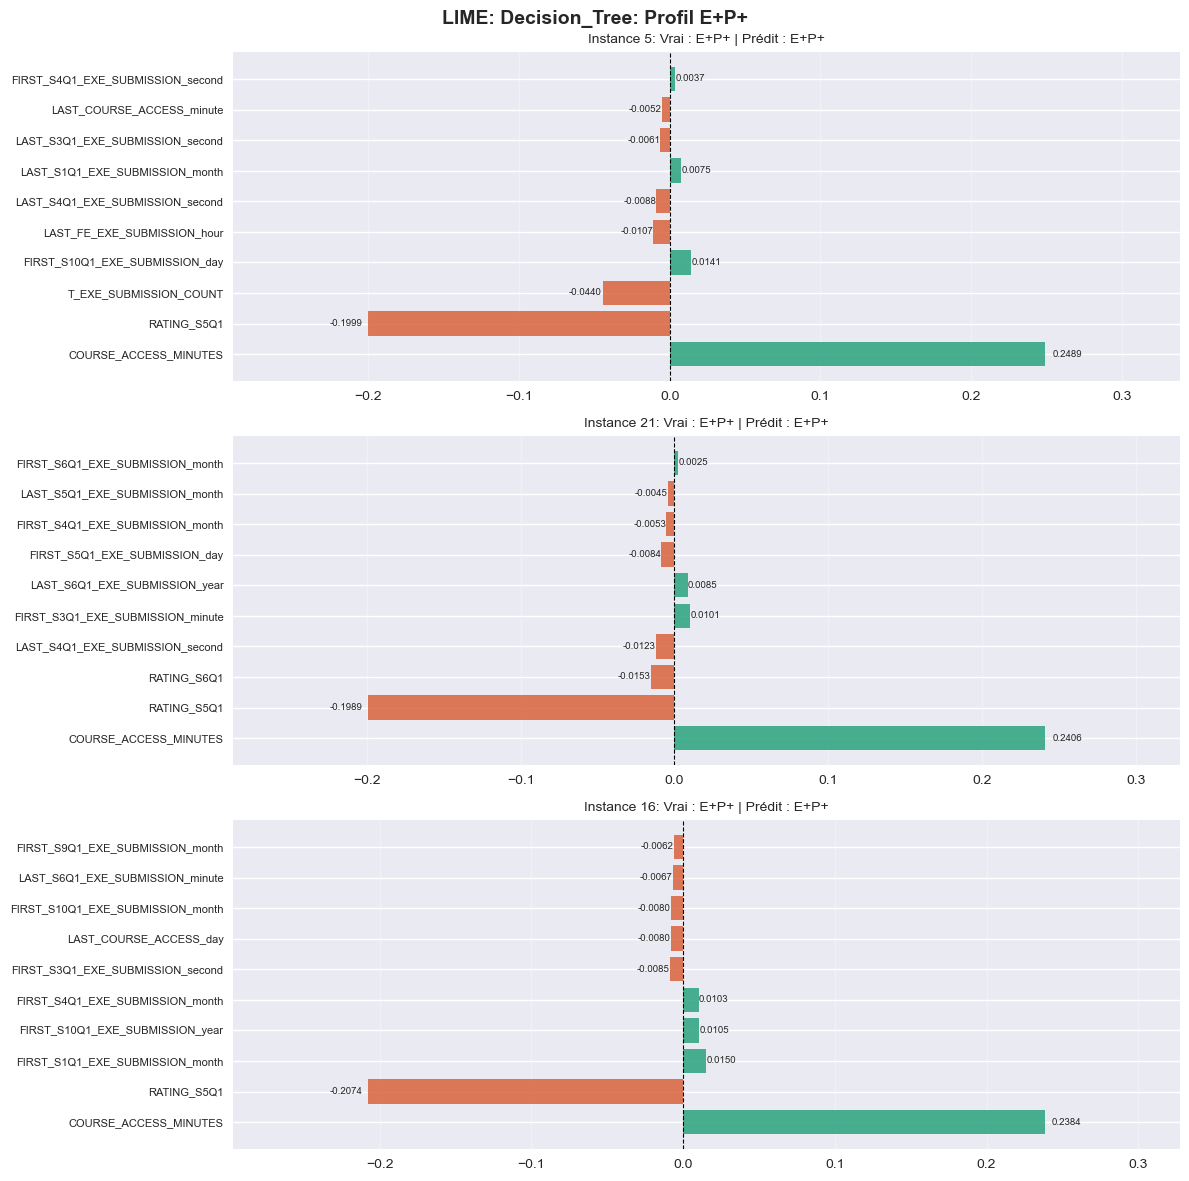

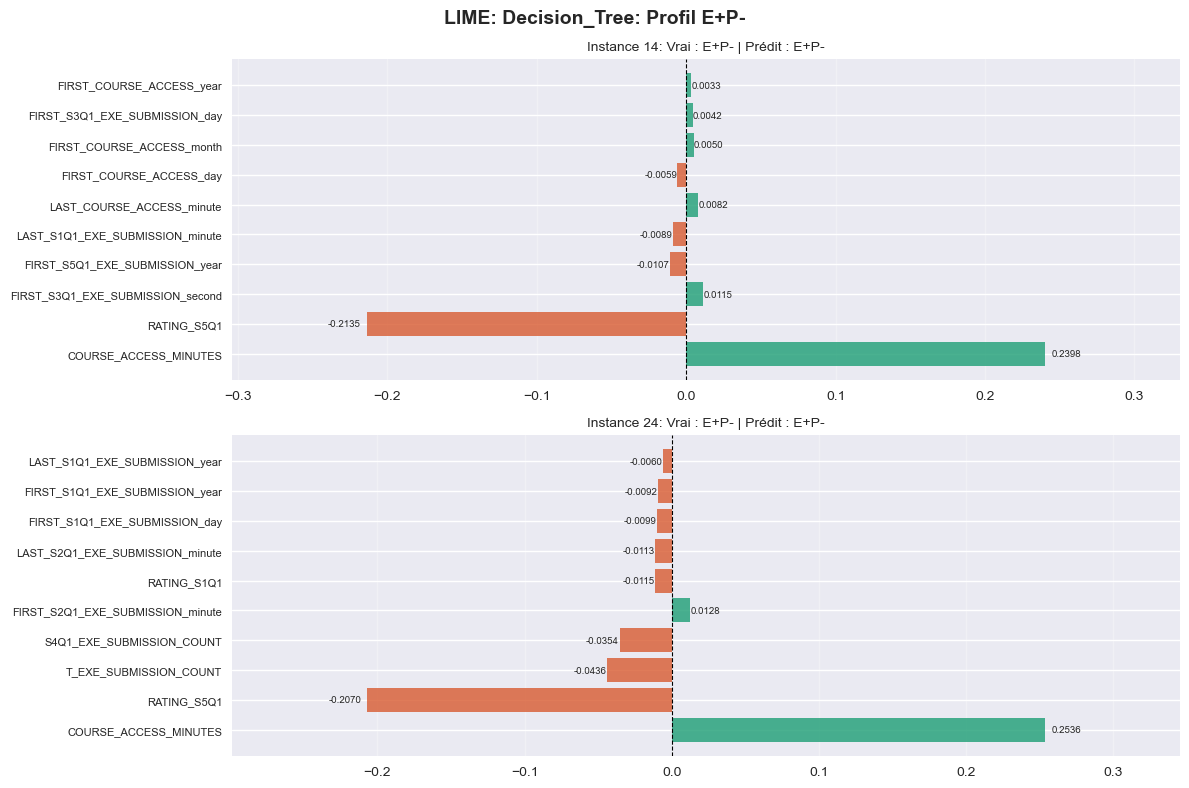

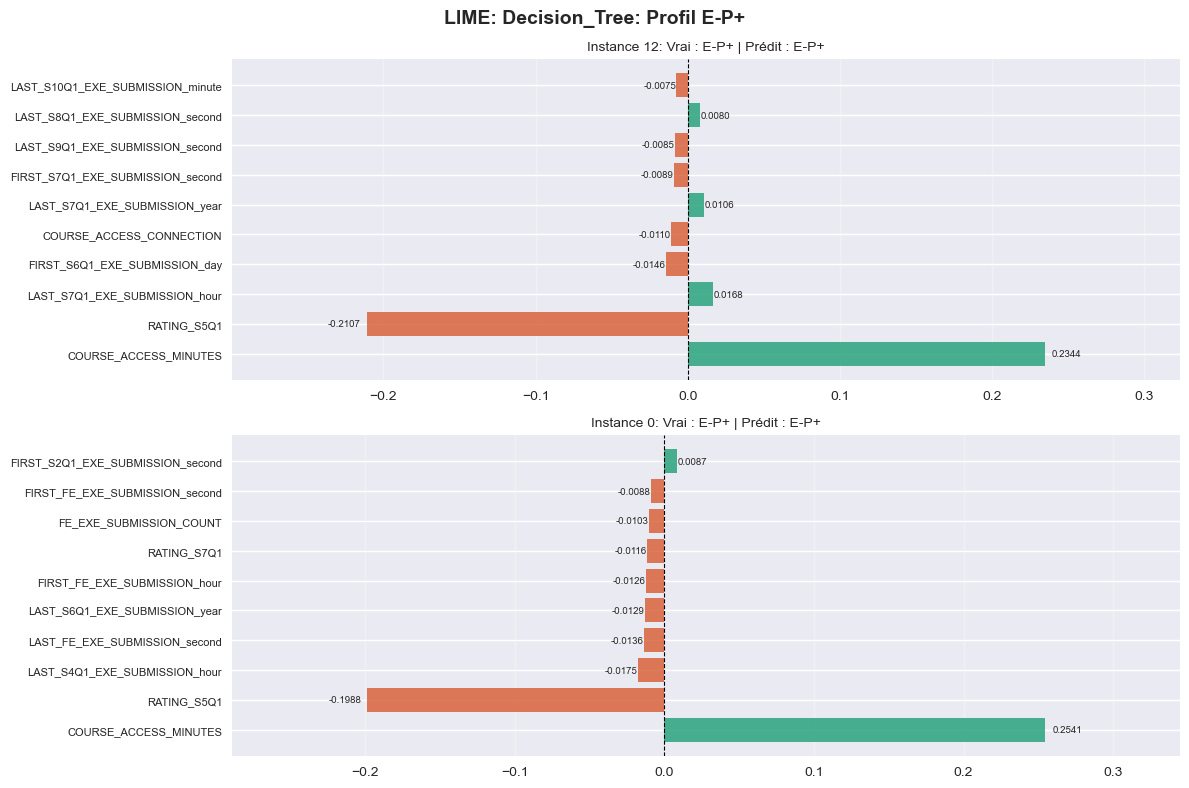

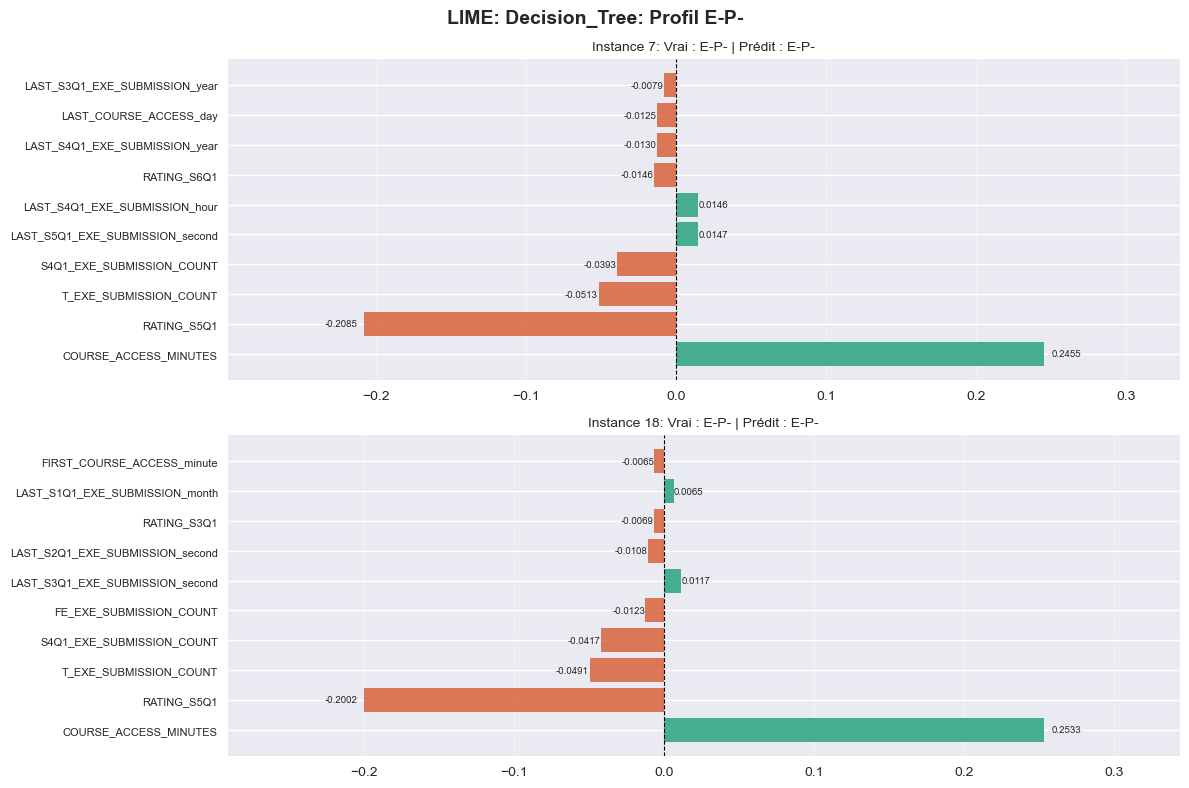

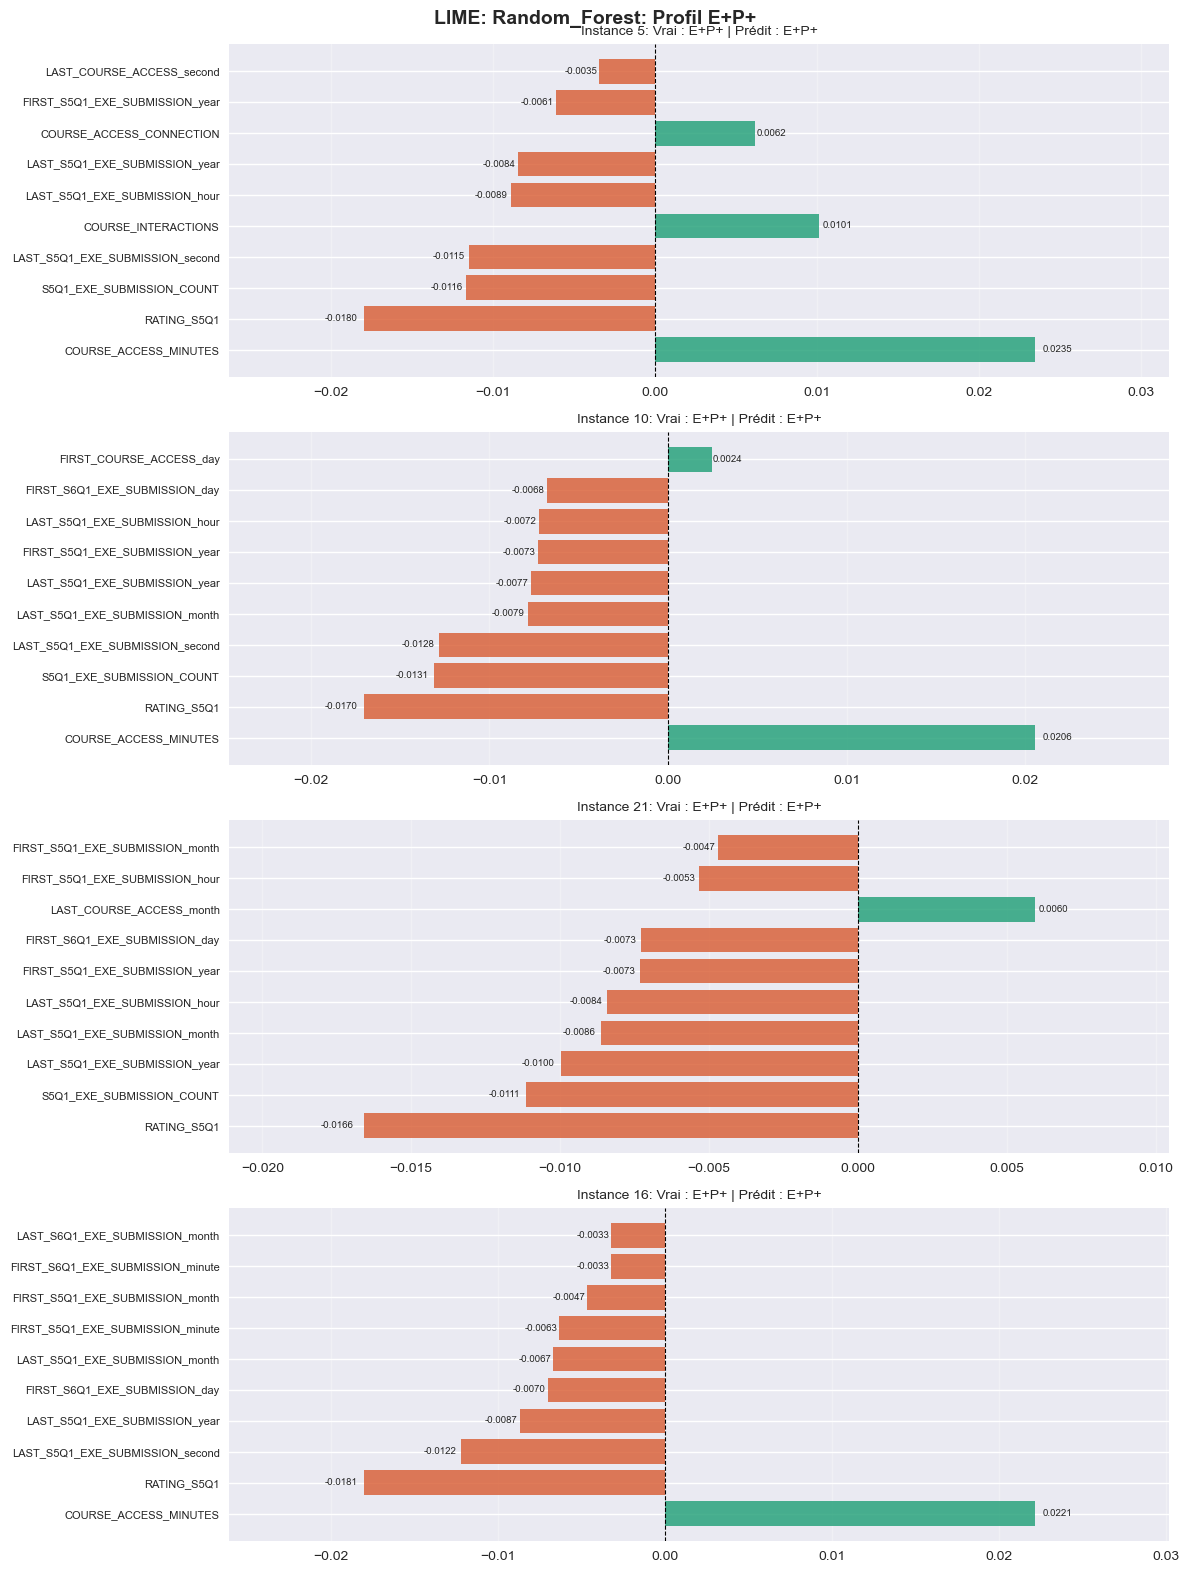

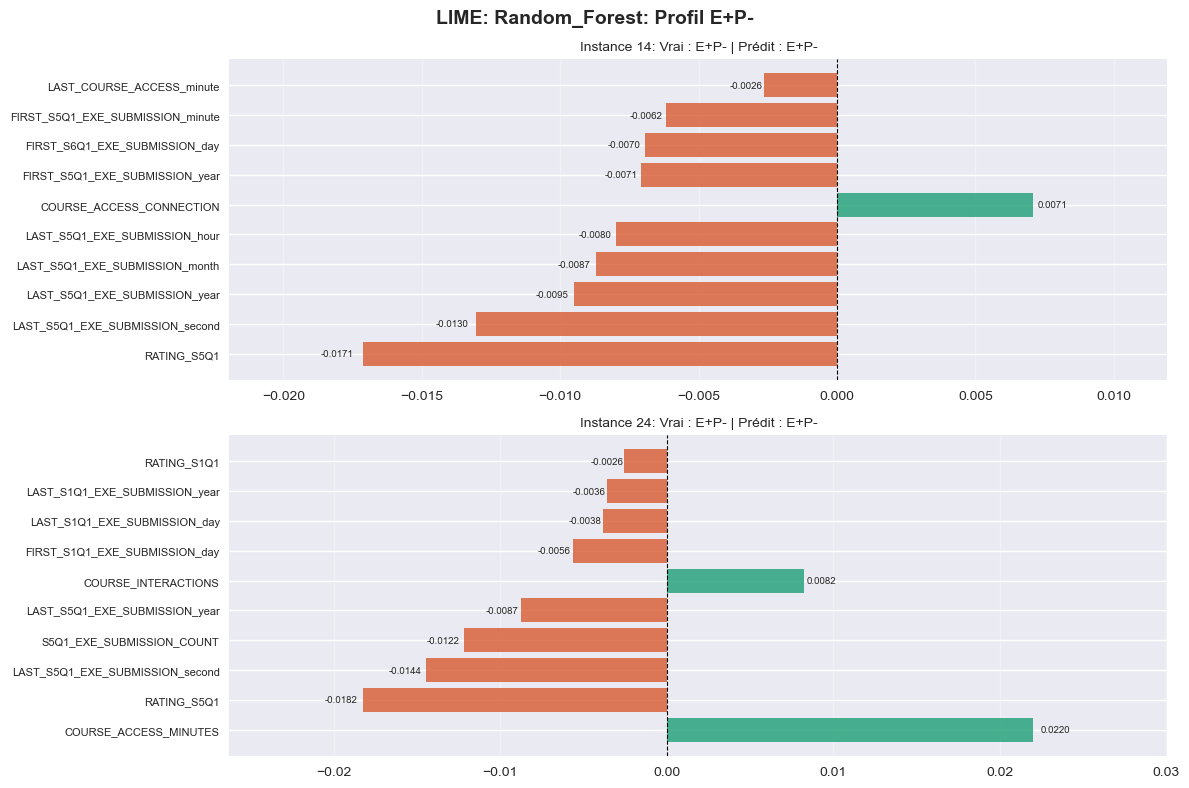

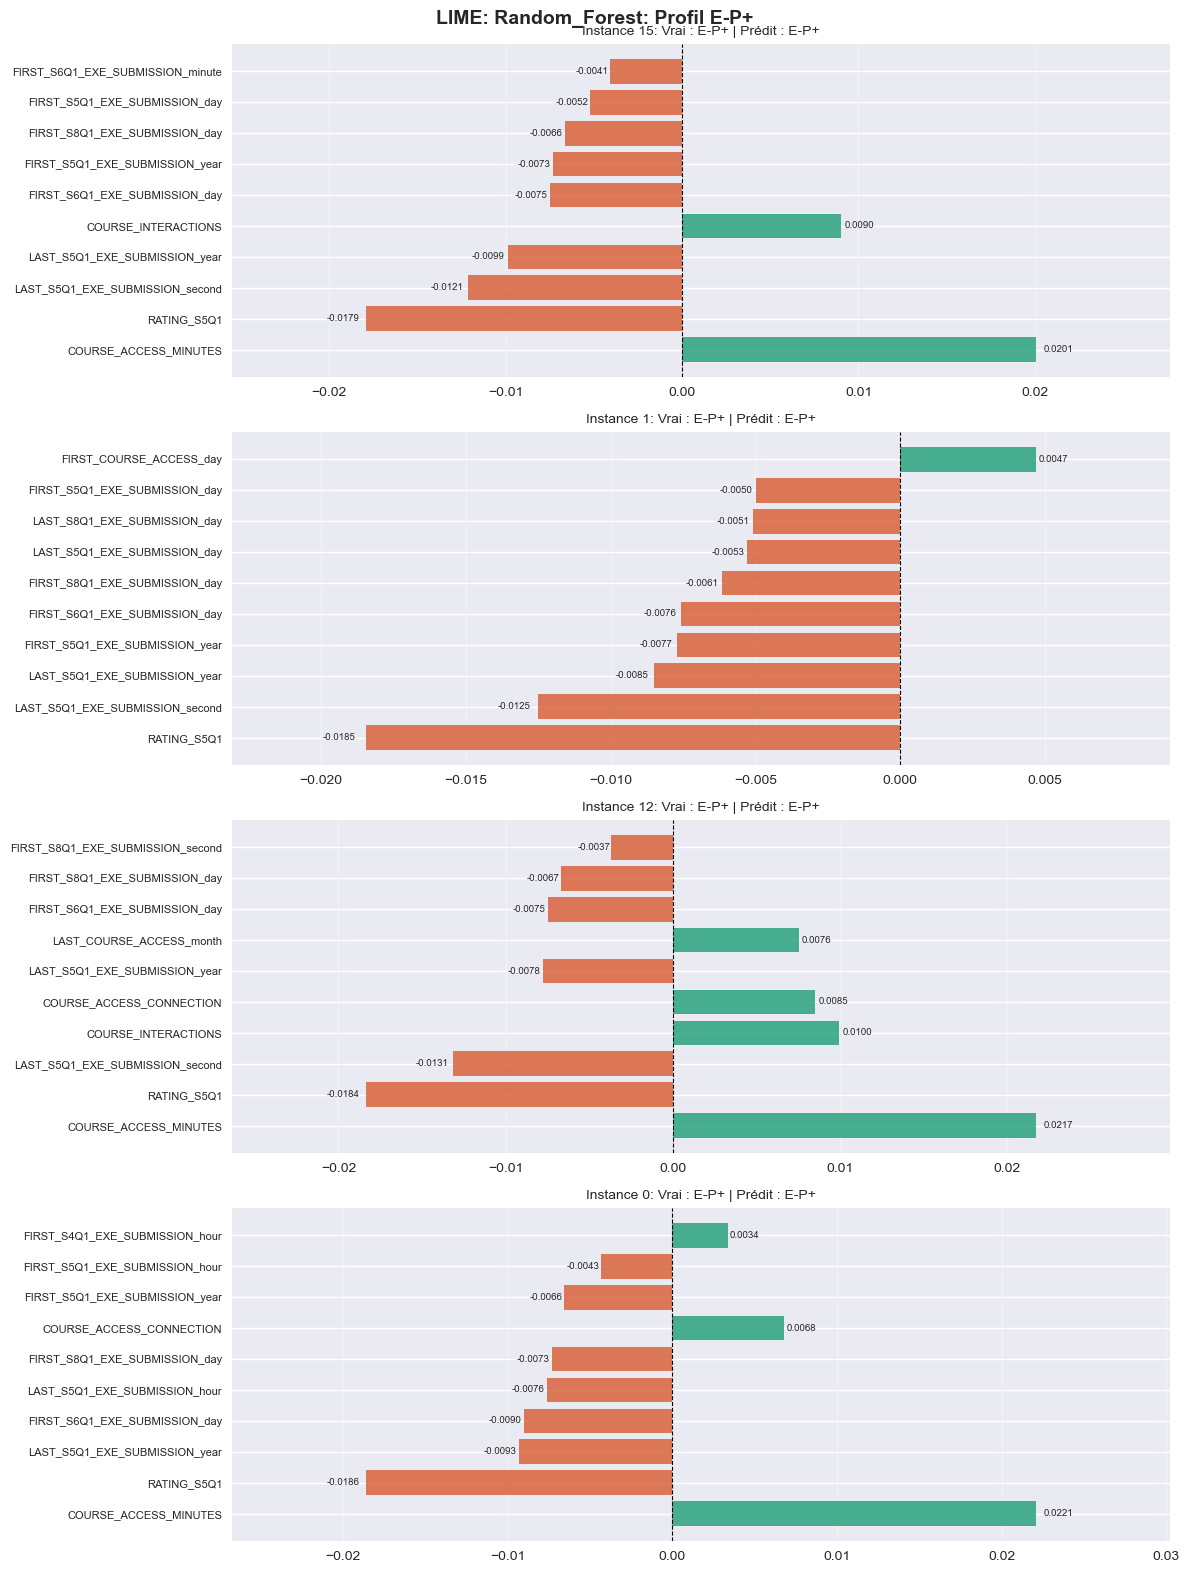

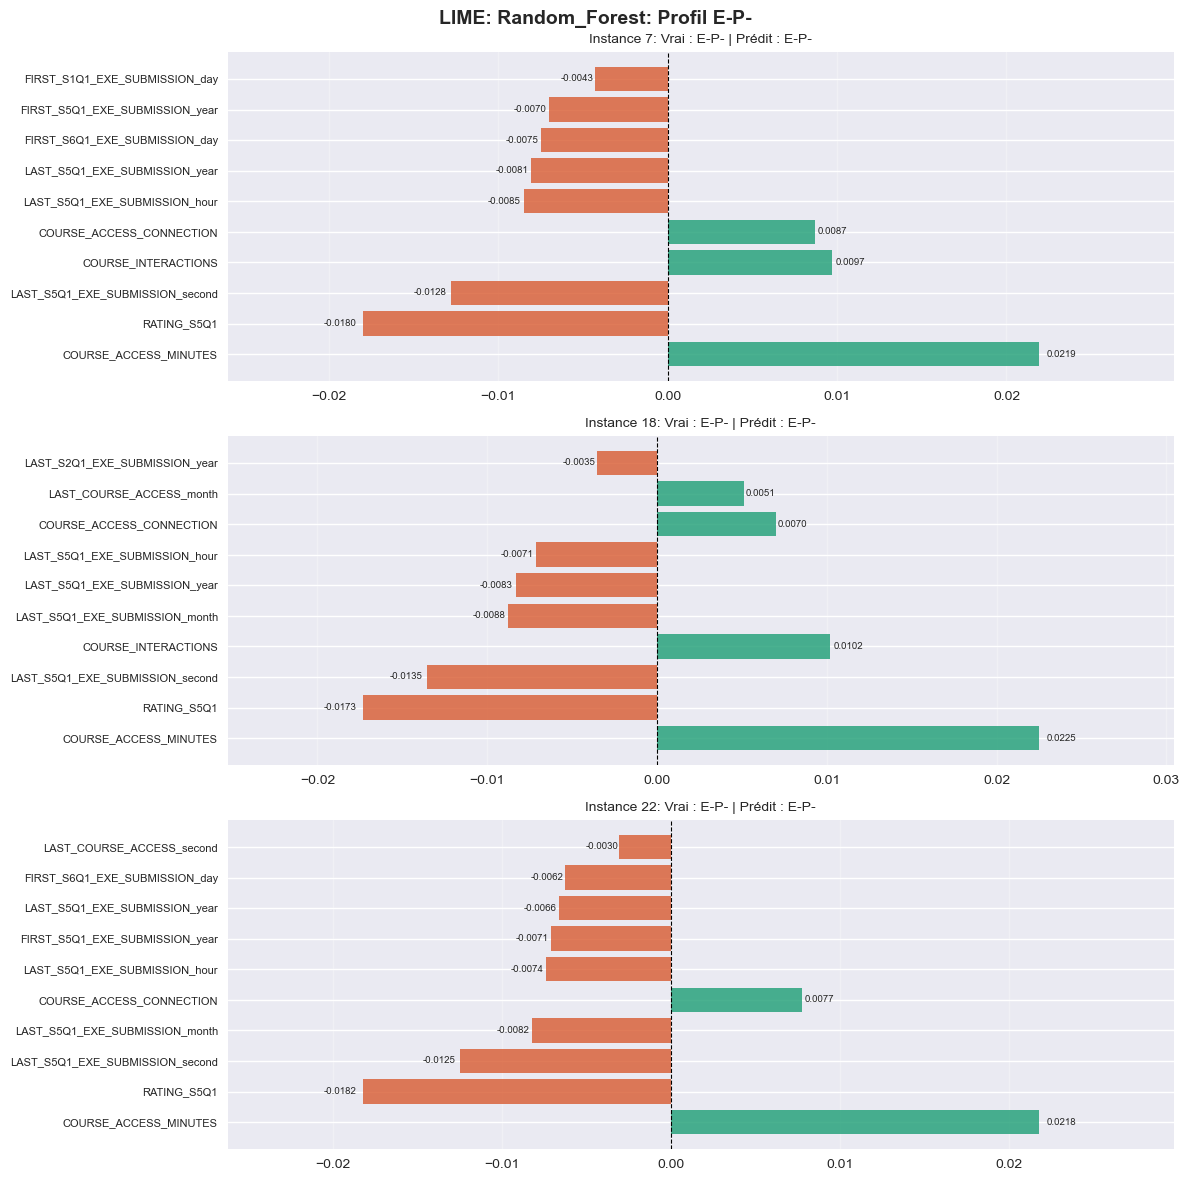

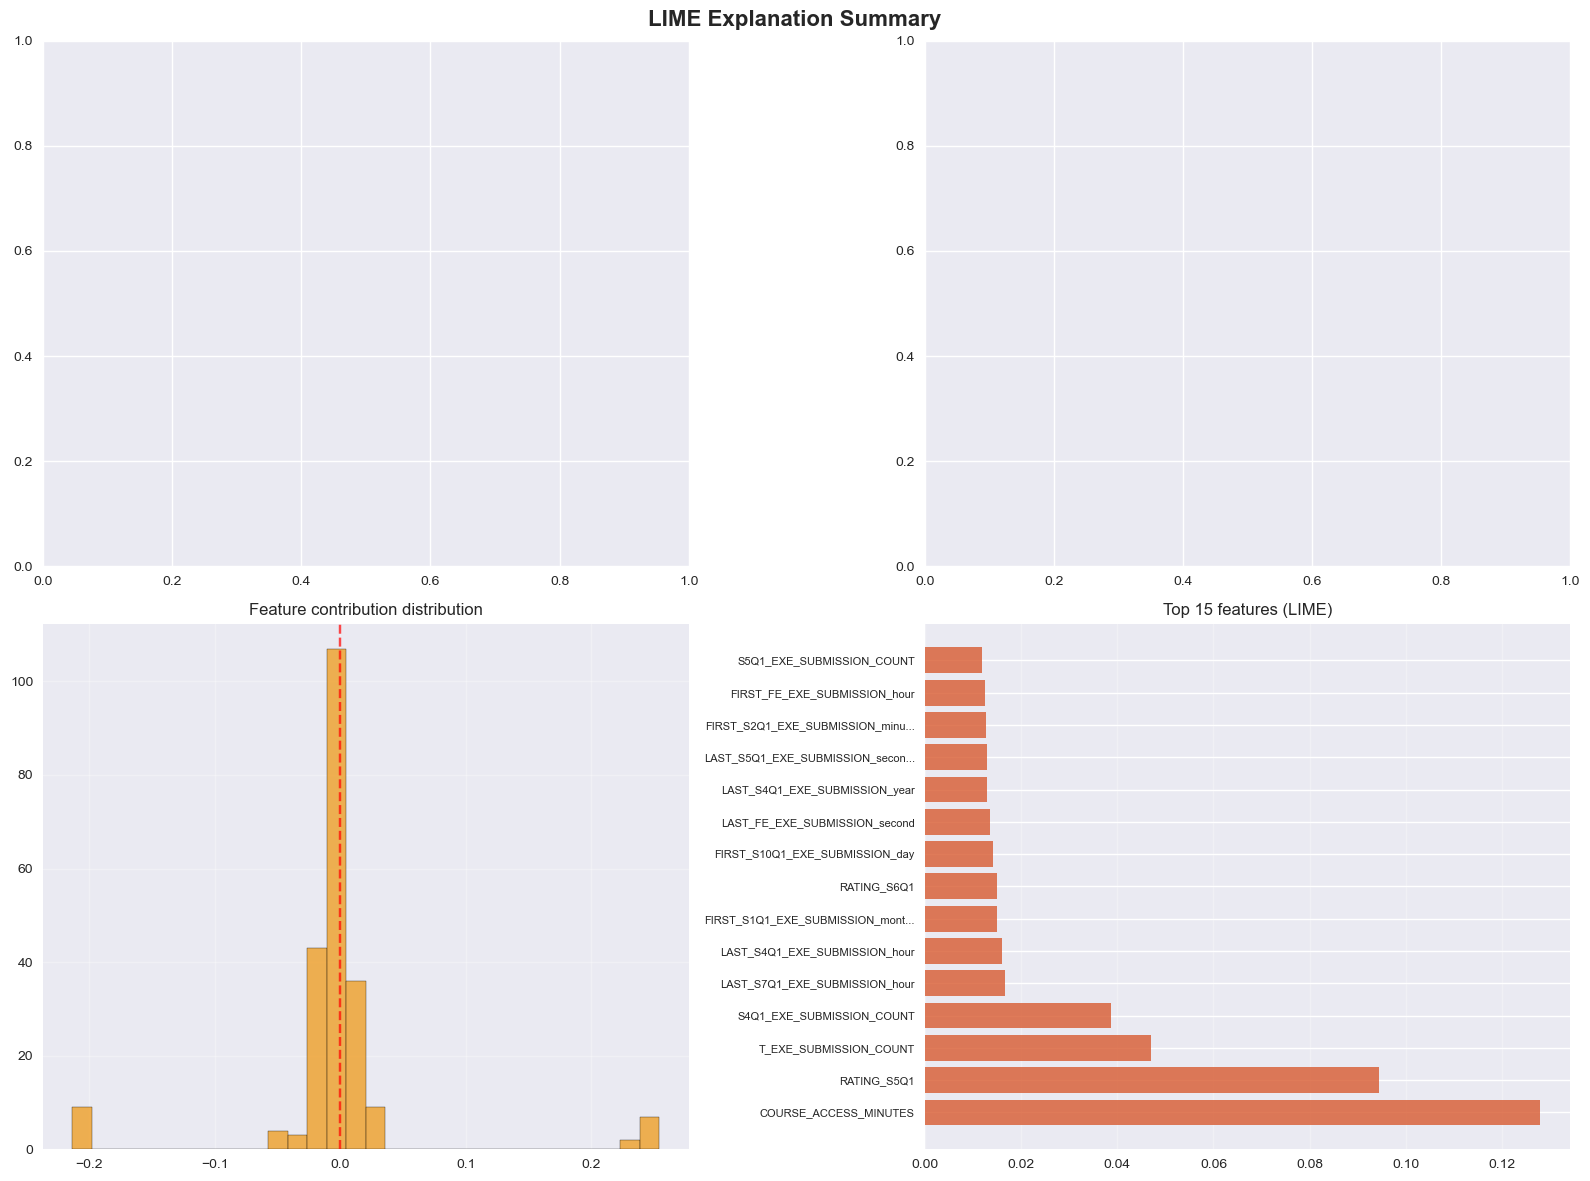


 LIME EXPLANATION QUALITY EVALUATION

  Decision_Tree
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Adva

In [28]:
lime_eval = LIMEEvaluator(evaluator)
lime_eval.run()

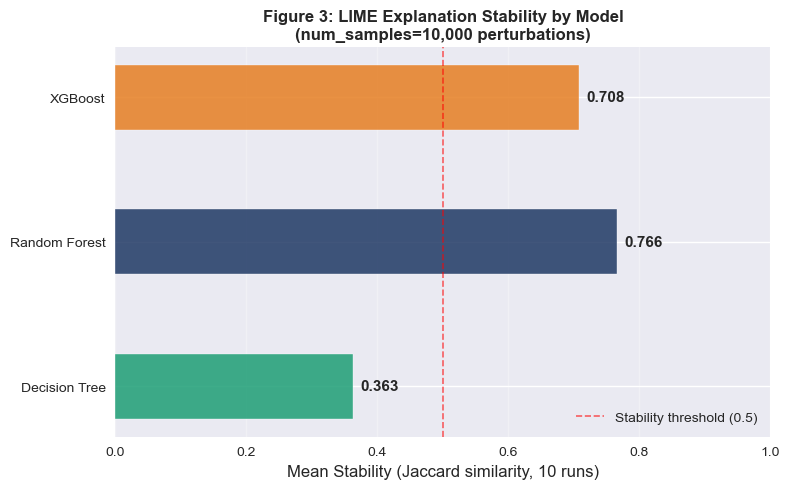

Saved: outputs/canva/fig3_lime_stability.png


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
os.makedirs('outputs/canva', exist_ok=True)

df_lime = pd.read_csv('outputs/lime_explanations.csv')

# Fig. 3: LIME stability by model 
stability_data = {
    'Decision Tree': 0.363,
    'Random Forest': 0.766,
    'XGBoost':       0.708,
}
colors = ['#1D9E75', '#1F3864', '#E67E22']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(
    list(stability_data.keys()),
    list(stability_data.values()),
    color=colors, alpha=0.85, edgecolor='white', height=0.45
)
ax.axvline(0.5, color='red', linestyle='--', linewidth=1.2, alpha=0.6,
           label='Stability threshold (0.5)')
ax.bar_label(bars, fmt='%.3f', padding=5, fontsize=11, fontweight='bold')
ax.set_xlabel('Mean Stability (Jaccard similarity, 10 runs)', fontsize=12)
ax.set_xlim(0, 1.0)
ax.set_title('Figure 3: LIME Explanation Stability by Model\n'
             '(num_samples=10,000 perturbations)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/canva/fig3_lime_stability.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: outputs/canva/fig3_lime_stability.png')

Available models: ['Decision_Tree' 'Random_Forest']
Total rows: 220

Top 10 features (10 found):
feature
FIRST_S6Q1_EXE_SUBMISSION_day      0.007325
COURSE_ACCESS_CONNECTION           0.007428
LAST_S5Q1_EXE_SUBMISSION_hour      0.007890
LAST_S5Q1_EXE_SUBMISSION_month     0.008146
LAST_S5Q1_EXE_SUBMISSION_year      0.008579
COURSE_INTERACTIONS                0.009541
S5Q1_EXE_SUBMISSION_COUNT          0.012019
LAST_S5Q1_EXE_SUBMISSION_second    0.012783
RATING_S5Q1                        0.017835
COURSE_ACCESS_MINUTES              0.021822
Name: abs_val, dtype: float64


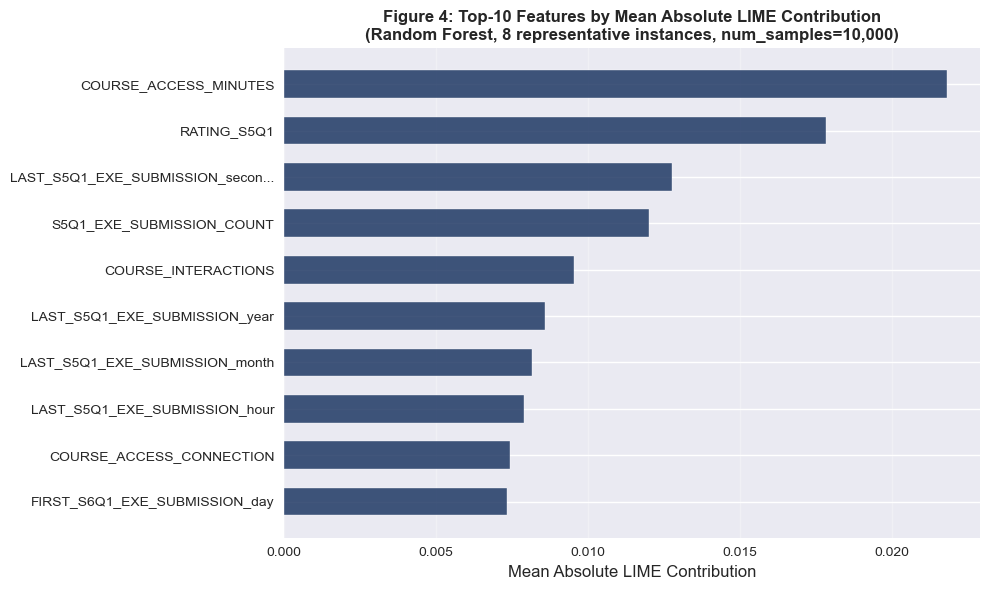

Saved: outputs/canva/fig4_lime_top10_rf.png


In [30]:
df_lime = pd.read_csv('outputs/lime_explanations.csv')

print("Available models:", df_lime['model'].unique())
print("Total rows:", len(df_lime))

# Use Random Forest (best LIME stability: 0.766)
df_rf = df_lime[df_lime['model'] == 'Random_Forest'].copy()
df_rf['abs_val'] = df_rf['contribution'].abs()

top10 = (df_rf.groupby('feature')['abs_val']
         .mean()
         .sort_values(ascending=True)
         .tail(10))

print(f"\nTop 10 features ({len(top10)} found):")
print(top10)

labels = [f[:30] + '...' if len(f) > 30 else f for f in top10.index]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(top10)), top10.values,
        color='#1F3864', alpha=0.85, edgecolor='white', height=0.6)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Mean Absolute LIME Contribution', fontsize=12)
ax.set_title('Figure 4: Top-10 Features by Mean Absolute LIME Contribution\n'
             '(Random Forest, 8 representative instances, num_samples=10,000)',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/canva/fig4_lime_top10_rf.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: outputs/canva/fig4_lime_top10_rf.png')

In [18]:
print("Columns:", df_lime.columns.tolist())
print("Models:", df_lime['model'].unique())
print("df_xgb rows:", len(df_xgb))

Columns: ['model', 'instance_id', 'profil', 'vrai_label', 'predit_label', 'proba_E+P+', 'proba_E+P-', 'proba_E-P+', 'proba_E-P-', 'feature', 'contribution', 'abs_contrib']
Models: ['Decision_Tree' 'Random_Forest']
df_xgb rows: 0
